<a href="https://colab.research.google.com/github/dhanwariagarvit21/cont-s-stylized-facts/blob/main/heavy_tails_Excess_kurtosis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [30]:
import pandas as pd
import numpy as np
import yfinance as yf
from scipy import stats
import matplotlib.pyplot as plt



In [31]:
one_minute_nifty = yf.download('^NSEI',period='7d',interval='1m')
one_year_nifty = yf.download('^NSEI',start = '2025-01-01',end = '2026-01-01')
one_minute_Reliance = yf.download('Reliance.NS',period='7d',interval='1m')
one_year_Reliance = yf.download('Reliance.NS',start = '2025-01-01',end = '2026-01-01')

/tmp/ipykernel_3025/1130229652.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  one_minute_nifty = yf.download('^NSEI',period='7d',interval='1m')
[*********************100%***********************]  1 of 1 completed
/tmp/ipykernel_3025/1130229652.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  one_year_nifty = yf.download('^NSEI',start = '2025-01-01',end = '2026-01-01')
[*********************100%***********************]  1 of 1 completed
/tmp/ipykernel_3025/1130229652.py:3: FutureWarning: YF.download() has changed argument auto_adjust default to True
  one_minute_Reliance = yf.download('Reliance.NS',period='7d',interval='1m')
[*********************100%***********************]  1 of 1 completed
/tmp/ipykernel_3025/1130229652.py:4: FutureWarning: YF.download() has changed argument auto_adjust default to True
  one_year_Reliance = yf.download('Reliance.NS',start = '2025-01-01',end = '2026-01-01')
[******************

In [32]:
def jarques_bera(X):
  x = np.asarray(X,dtype=float)
  n = len(X)
  x_bar = np.mean(x)
  diffs = x - x_bar
  mu2 = np.mean(diffs**2)
  mu3 = np.mean(diffs**3)
  mu4 = np.mean(diffs**4)
  S = mu3/mu2**1.5
  K = mu4/mu2**2 - 3
  jb_Stat = (n/6.0) * (S ** 2 + (K ** 2)/4.0)
  p_val = 1 - stats.chi2.cdf(jb_Stat, 2)
  return jb_Stat,p_val,S,K

In [33]:
print('--- one_minute_nifty ---')
jb_stat_omn, p_val_omn, s_omn, k_omn = jarques_bera(np.log(one_minute_nifty['Close']/one_minute_nifty['Close'].shift(1)).dropna())
print(f"JB Statistic: {jb_stat_omn:.2f}")
print(f"P-value: {p_val_omn:.4f}")
print(f"Skewness: {s_omn:.4f}")
print(f"Kurtosis: {k_omn:.4f}\n")
print('--- one_year_nifty ---')
jb_stat_oyn, p_val_oyn, s_oyn, k_oyn = jarques_bera(np.log(one_year_nifty['Close']/one_year_nifty['Close'].shift(1)).dropna())
print(f"JB Statistic: {jb_stat_oyn:.2f}")
print(f"P-value: {p_val_oyn:.4f}")
print(f"Skewness: {s_oyn:.4f}")
print(f"Kurtosis: {k_oyn:.4f}\n")
print('--- one_minute_Reliance ---')
jb_stat_omr, p_val_omr, s_omr, k_omr = jarques_bera(np.log(one_minute_Reliance['Close']/one_minute_Reliance['Close'].shift(1)).dropna())
print(f"JB Statistic: {jb_stat_omr:.2f}")
print(f"P-value: {p_val_omr:.4f}")
print(f"Skewness: {s_omr:.4f}")
print(f"Kurtosis: {k_omr:.4f}\n")
print('--- one_year_Reliance ---')
jb_stat_oyr, p_val_oyr, s_oyr, k_oyr = jarques_bera(np.log(one_year_Reliance['Close']/one_year_Reliance['Close'].shift(1)).dropna())
print(f"JB Statistic: {jb_stat_oyr:.2f}")
print(f"P-value: {p_val_oyr:.4f}")
print(f"Skewness: {s_oyr:.4f}")
print(f"Kurtosis: {k_oyr:.4f}\n")

--- one_minute_nifty ---
JB Statistic: 8723843.38
P-value: 0.0000
Skewness: 7.7731
Kurtosis: 282.0453

--- one_year_nifty ---
JB Statistic: 128.20
P-value: 0.0000
Skewness: 0.2802
Kurtosis: 3.4774

--- one_minute_Reliance ---
JB Statistic: 216227.61
P-value: 0.0000
Skewness: 1.1158
Kurtosis: 45.0213

--- one_year_Reliance ---
JB Statistic: 36.10
P-value: 0.0000
Skewness: 0.4774
Kurtosis: 1.6066



In [34]:
datasets = ['one_minute_nifty', 'one_year_nifty', 'one_minute_Reliance', 'one_year_Reliance']

jb_stats = [
    jb_stat_omn,
    jb_stat_oyn,
    jb_stat_omr,
    jb_stat_oyr
]
p_values = [
    p_val_omn,
    p_val_oyn,
    p_val_omr,
    p_val_oyr
]
skewness = [
    s_omn,
    s_oyn,
    s_omr,
    s_oyr
]
kurtosis = [
    k_omn,
    k_oyn,
    k_omr,
    k_oyr
]

jb_results_df = pd.DataFrame({
    'Dataset': datasets,
    'JB Statistic': jb_stats,
    'P-value': p_values,
    'Skewness': skewness,
    'Kurtosis': kurtosis
})

display(jb_results_df)

,Dataset,JB Statistic,P-value,Skewness,Kurtosis
0,one_minute_nifty,8.723843e+06,0.000000e+00,7.773110,282.045325
1,one_year_nifty,1.281969e+02,0.000000e+00,0.280176,3.477377
2,one_minute_Reliance,2.162276e+05,0.000000e+00,1.115778,45.021286
3,one_year_Reliance,3.609510e+01,1.452274e-08,0.477440,1.606636


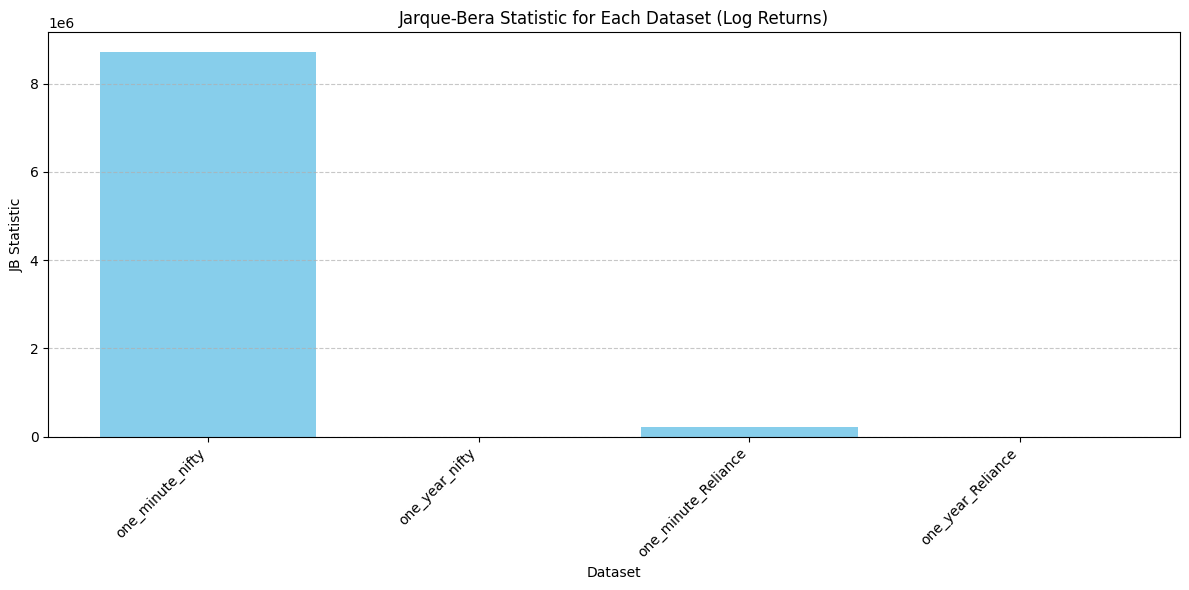

In [35]:
plt.figure(figsize=(12, 6))
plt.bar(jb_results_df['Dataset'], jb_results_df['JB Statistic'], color='skyblue')
plt.title('Jarque-Bera Statistic for Each Dataset (Log Returns)')
plt.xlabel('Dataset')
plt.ylabel('JB Statistic')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

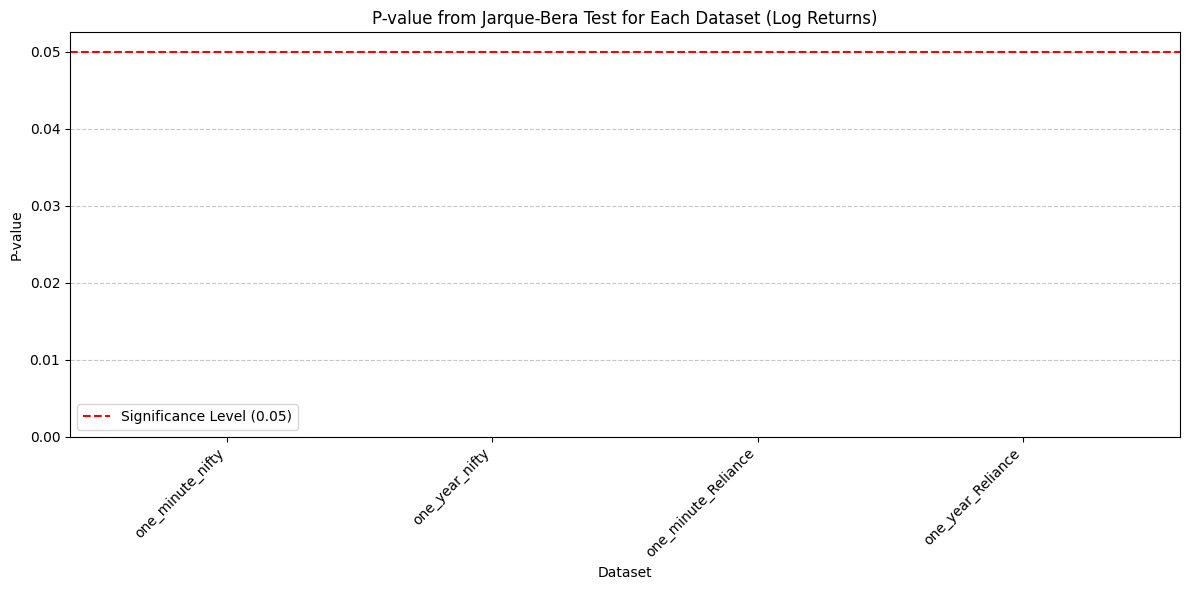

In [36]:
plt.figure(figsize=(12, 6))
plt.bar(jb_results_df['Dataset'], jb_results_df['P-value'], color='lightcoral')
plt.title('P-value from Jarque-Bera Test for Each Dataset (Log Returns)')
plt.xlabel('Dataset')
plt.ylabel('P-value')
plt.xticks(rotation=45, ha='right')
plt.axhline(y=0.05, color='r', linestyle='--', label='Significance Level (0.05)')
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

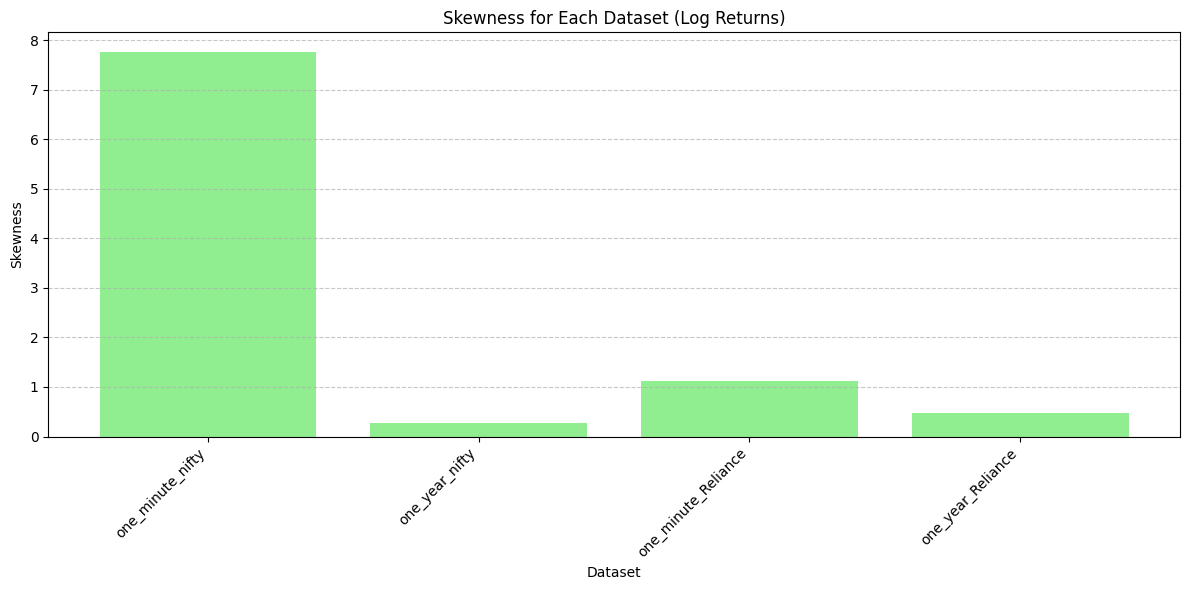

In [37]:
plt.figure(figsize=(12, 6))
plt.bar(jb_results_df['Dataset'], jb_results_df['Skewness'], color='lightgreen')
plt.title('Skewness for Each Dataset (Log Returns)')
plt.xlabel('Dataset')
plt.ylabel('Skewness')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

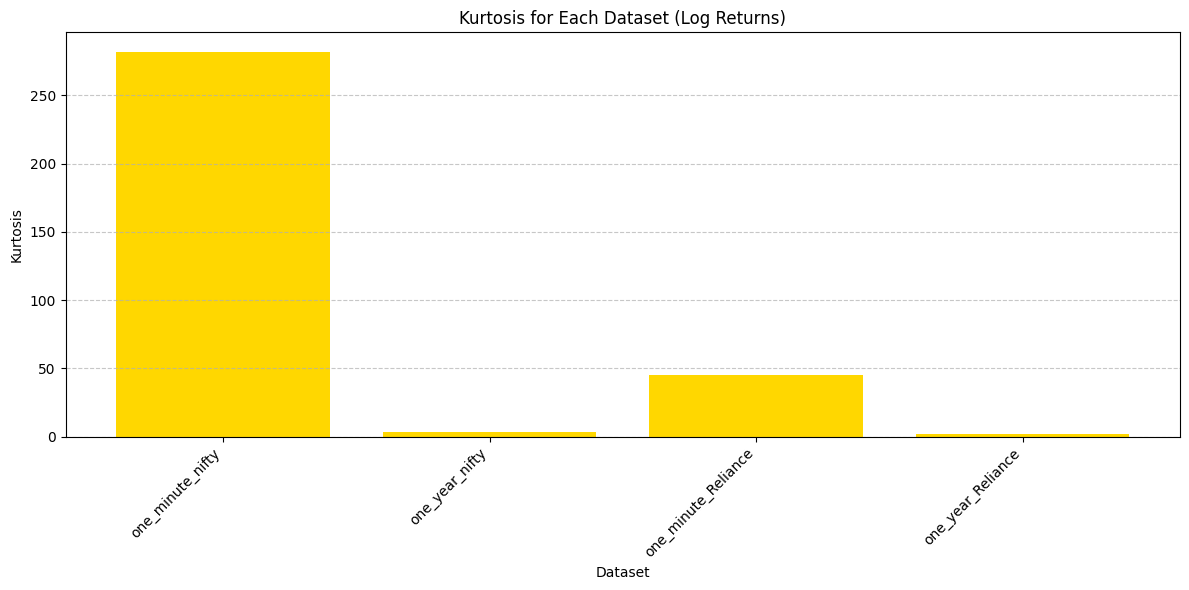

In [38]:
plt.figure(figsize=(12, 6))
plt.bar(jb_results_df['Dataset'], jb_results_df['Kurtosis'], color='gold')
plt.title('Kurtosis for Each Dataset (Log Returns)')
plt.xlabel('Dataset')
plt.ylabel('Kurtosis')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [39]:
def hill_estimator(x, k):
    x_positive = np.abs(x[x != 0])
    if len(x_positive) < k or k <= 0:
        return np.nan
    x_sorted = np.sort(x_positive)[::-1]
    threshold_value = x_sorted[k]
    if threshold_value <= 0:
        return np.nan
    log_ratios_sum = np.sum(np.log(x_sorted[:k] / threshold_value))
    if log_ratios_sum == 0:
        return np.nan
    return k / log_ratios_sum

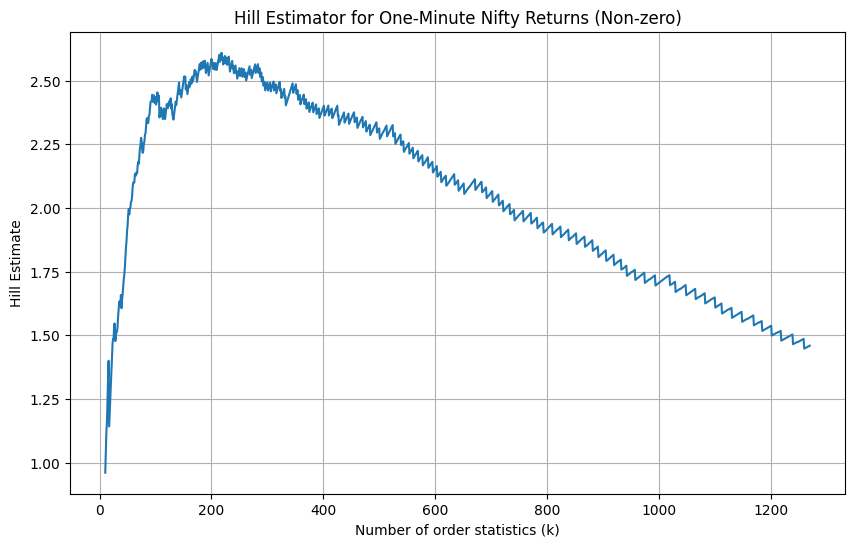

In [40]:
raw_returns = one_minute_nifty['Close'].diff().dropna().values
x = raw_returns[raw_returns != 0]
n = len(x)
k_values = np.arange(10, n // 2, 1)
hill_estimates = [hill_estimator(x, k) for k in k_values]

plt.figure(figsize=(10, 6))
plt.plot(k_values, hill_estimates)
plt.title('Hill Estimator for One-Minute Nifty Returns (Non-zero)')
plt.xlabel('Number of order statistics (k)')
plt.ylabel('Hill Estimate')
plt.grid(True)
plt.show()

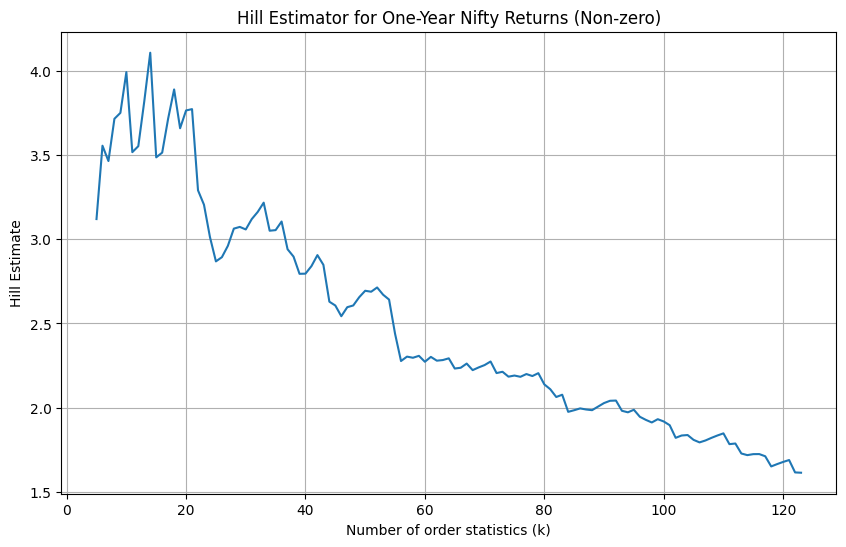

In [41]:
raw_returns = one_year_nifty['Close'].diff().dropna().values
x = raw_returns[raw_returns != 0]
n = len(x)
k_values = np.arange(5, n // 2, 1)
hill_estimates = [hill_estimator(x, k) for k in k_values]

plt.figure(figsize=(10, 6))
plt.plot(k_values, hill_estimates)
plt.title('Hill Estimator for One-Year Nifty Returns (Non-zero)')
plt.xlabel('Number of order statistics (k)')
plt.ylabel('Hill Estimate')
plt.grid(True)
plt.show()

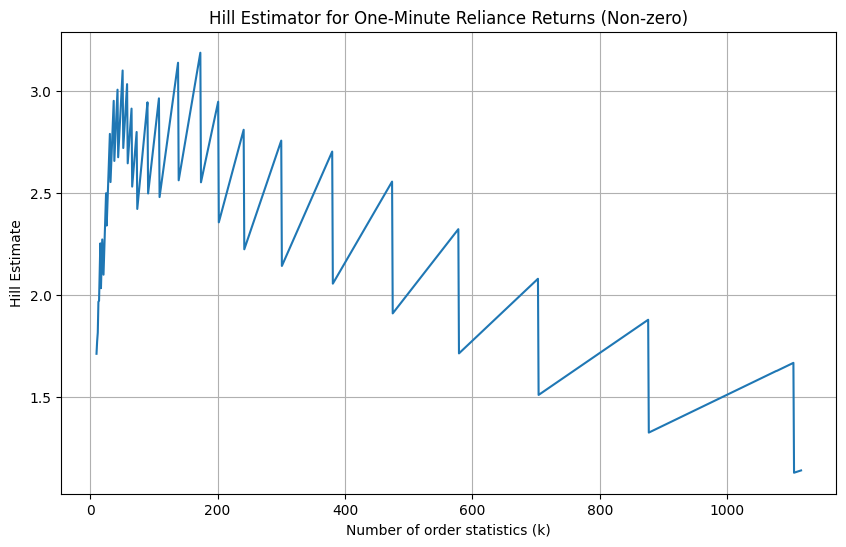

In [42]:
raw_returns = one_minute_Reliance['Close'].diff().dropna().values
x = raw_returns[raw_returns != 0]
n = len(x)
k_values = np.arange(10, n // 2, 1)
hill_estimates = [hill_estimator(x, k) for k in k_values]

plt.figure(figsize=(10, 6))
plt.plot(k_values, hill_estimates)
plt.title('Hill Estimator for One-Minute Reliance Returns (Non-zero)')
plt.xlabel('Number of order statistics (k)')
plt.ylabel('Hill Estimate')
plt.grid(True)
plt.show()

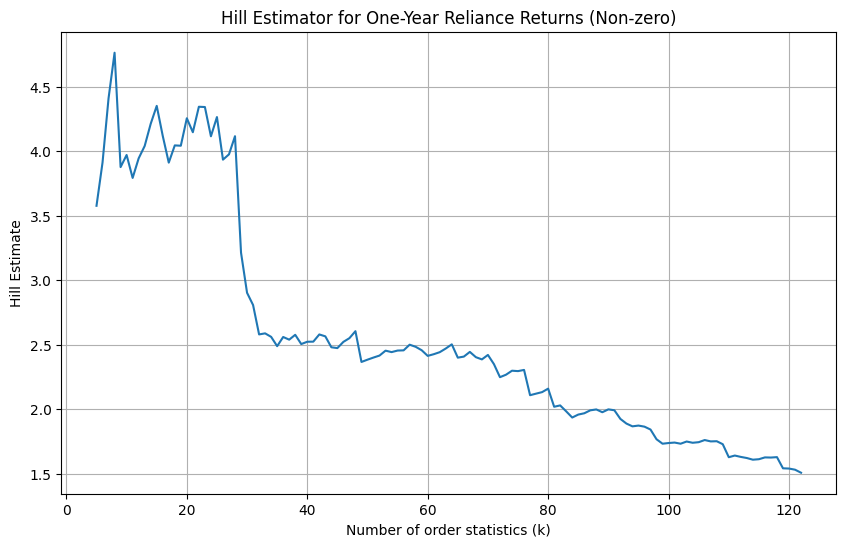

In [43]:

raw_returns = one_year_Reliance['Close'].diff().dropna().values
x = raw_returns[raw_returns != 0]
n = len(x)
k_values = np.arange(5, n // 2, 1)
hill_estimates = [hill_estimator(x, k) for k in k_values]

plt.figure(figsize=(10, 6))
plt.plot(k_values, hill_estimates)
plt.title('Hill Estimator for One-Year Reliance Returns (Non-zero)')
plt.xlabel('Number of order statistics (k)')
plt.ylabel('Hill Estimate')
plt.grid(True)
plt.show()